                                                                  file  observed_C1s_peak_eV  applied_shift_eV
 Al203_run1_10_Al203_run1_3_15-3 1hr_HR (SCCM Ar : SCCM O2 = 15:3).csv                 286.9              -2.1
Al203_run1_107_Al203_run1_2_12-6 1hr_HR (SCCM Ar : SCCM O2 = 12:6).csv                 286.5              -1.7
   Al203_run1_109_Al203_run1_4_9-9 1h_HR (SCCM Ar : SCCM O2 = 9:9).csv                 287.0              -2.2


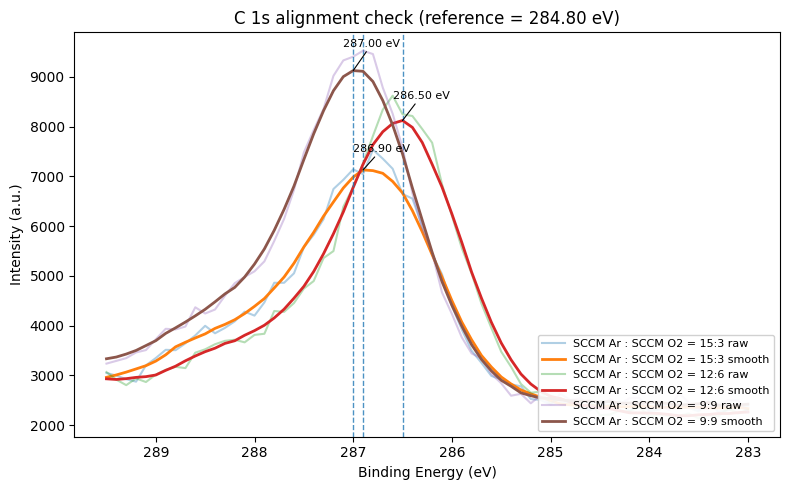


Detected shifted Al2p peak positions:
                                                                  file region  shifted_peak_eV
 Al203_run1_10_Al203_run1_3_15-3 1hr_HR (SCCM Ar : SCCM O2 = 15:3).csv   Al2p             74.1
Al203_run1_107_Al203_run1_2_12-6 1hr_HR (SCCM Ar : SCCM O2 = 12:6).csv   Al2p             74.2
   Al203_run1_109_Al203_run1_4_9-9 1h_HR (SCCM Ar : SCCM O2 = 9:9).csv   Al2p             74.2


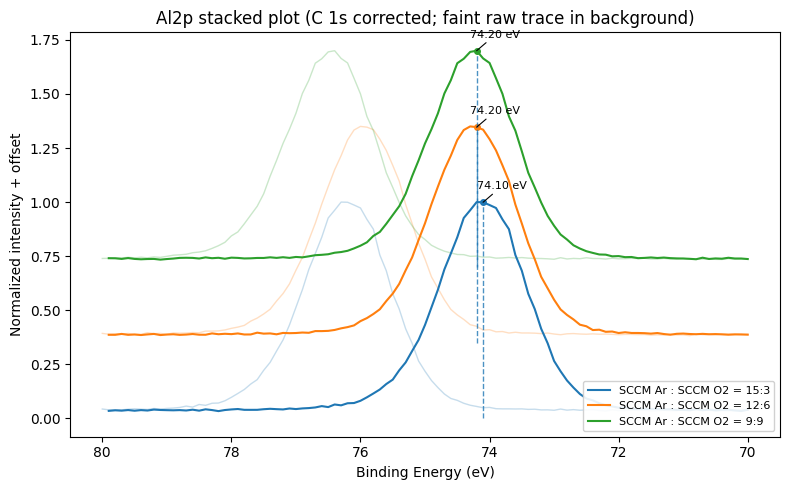


Detected shifted O1s peak positions:
                                                                  file region  shifted_peak_eV
 Al203_run1_10_Al203_run1_3_15-3 1hr_HR (SCCM Ar : SCCM O2 = 15:3).csv    O1s            531.1
Al203_run1_107_Al203_run1_2_12-6 1hr_HR (SCCM Ar : SCCM O2 = 12:6).csv    O1s            531.1
   Al203_run1_109_Al203_run1_4_9-9 1h_HR (SCCM Ar : SCCM O2 = 9:9).csv    O1s            531.3


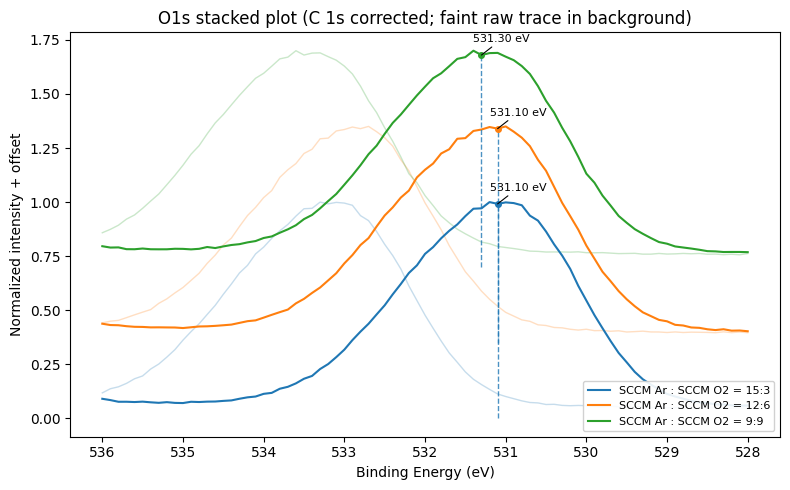

In [4]:
import os
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
DRIVE_FOLDER = "/content/drive/MyDrive/Hfab final project/XPS Data/3-20-26"
FILE_GLOB = "*.csv"

# Regions to plot. Use exact names from your files if you know them.
AL_REGIONS_TO_PLOT = ["Al2p"]
O_REGIONS_TO_PLOT = ["O1s"]

# C 1s charging correction
C_REGION_NAME = "C1s"
C_REFERENCE_BE = 284.8           # eV
C_SEARCH_WINDOW = (283.0, 289.5) # eV window used to find the C peak
C_SMOOTH_POINTS = 7              # moving-average points used only for peak finding

# Plot windows (set to None to use the full region)
PLOT_WINDOWS = {
    "Al2p": (70, 80),
    "O1s": (528, 536),
    # "Al2s": (112, 125),
}

# Peak-search windows for annotation after C 1s shifting.
# If a region is omitted here, the code falls back to that region's plot window.
PEAK_SEARCH_WINDOWS = {
    "Al2p": (72, 76),
    "O1s": (529, 534),
    # "Al2s": (116, 121),
}
SMOOTH_POINTS_FOR_PEAKS = 7
ANNOTATE_PEAKS = True
PEAK_LABEL_X_SHIFT = 0.10    # eV shift for text relative to peak marker
PEAK_LABEL_Y_SHIFT = 0.05    # vertical shift for text relative to peak marker
SHOW_PEAK_MARKERS = True
PEAK_LINESTYLE = "--"
PEAK_LINEWIDTH = 1.0
PEAK_LINE_ALPHA = 0.8
C_PEAK_LABEL_Y_FRAC = 0.06   # label height as fraction of C-plot y-range above local peak

# Intensity handling
NORMALIZE_EACH_TRACE = True      # normalize each plotted trace to its own max inside the plotted window
VERTICAL_OFFSET = 0.35           # vertical offset between traces after normalization
GLOBAL_INTENSITY_SCALE = 1.0     # scales all traces together

# Optional extra per-file intensity multipliers
# Keys can be full file names or stems. Example:
# FILE_INTENSITY_MULTIPLIERS = {
#     "sample_1.csv": 1.0,
#     "sample_2.csv": 0.8,
#     "sample_3": 1.3,
# }
FILE_INTENSITY_MULTIPLIERS = {}

# Legend placement inside the plot
LEGEND_INSIDE = True
LEGEND_LOC = "lower right"
LEGEND_FONTSIZE = 8
LEGEND_NCOL = 1
LEGEND_FRAMEON = True
LEGEND_FACEALPHA = 0.9

# Optional raw-region overlay on shifted Al/O plots
SHOW_UNSHIFTED_BACKGROUND = True
UNSHIFTED_BACKGROUND_ALPHA = 0.25
UNSHIFTED_BACKGROUND_LINEWIDTH = 1.0
UNSHIFTED_BACKGROUND_COLOR_MODE = "same"   # "same" or "gray"
UNSHIFTED_BACKGROUND_GRAY = "0.65"

# Display / save options
REVERSE_X_AXIS = True            # standard for XPS
SHOW_C1S_QC_PLOT = True          # plot C 1s peak finding result for each file
SAVE_FIGURES = False
SAVE_FOLDER = None               # None -> saves into DRIVE_FOLDER if SAVE_FIGURES=True

# =========================
# HELPERS
# =========================
def parse_hr_xps_csv(path):
    """
    Parses CSVs of the format in your uploaded file.
    Returns:
        dict[region_name] = DataFrame(columns=["BE", "Intensity"])
    """
    with open(path, "r", errors="replace") as f:
        lines = [line.strip() for line in f]

    regions = {}
    i = 0
    while i < len(lines):
        line = lines[i]

        if not line:
            i += 1
            continue

        if re.fullmatch(r"\d+", line):
            if i + 4 < len(lines):
                region_name = lines[i + 2]
                grid_line = lines[i + 3]
                file_line = lines[i + 4]

                if re.fullmatch(r"\d+,\d+", grid_line) and file_line.lower().startswith("file#"):
                    data = []
                    j = i + 5
                    while j < len(lines):
                        s = lines[j]
                        if not s:
                            break
                        parts = s.split(",")
                        if len(parts) != 2:
                            break
                        try:
                            be = float(parts[0])
                            intensity = float(parts[1])
                            data.append((be, intensity))
                            j += 1
                        except ValueError:
                            break

                    if data:
                        df = pd.DataFrame(data, columns=["BE", "Intensity"])
                        regions[region_name] = df

                    i = j + 1
                    continue

        i += 1

    return regions


def moving_average(y, points=7):
    y = np.asarray(y, dtype=float)
    if points is None or points <= 1:
        return y.copy()
    return pd.Series(y).rolling(points, center=True, min_periods=1).mean().to_numpy()


def subset_window(df, window=None, be_col="BE"):
    if window is None:
        return df.copy()
    lo, hi = sorted(window)
    return df[(df[be_col] >= lo) & (df[be_col] <= hi)].copy()


def get_peak_position(df, search_window=None, smooth_points=7, be_col="BE", intensity_col="Intensity"):
    d = subset_window(df, search_window, be_col=be_col)
    if d.empty:
        raise ValueError("No data found in the requested peak-search window.")

    y_smooth = moving_average(d[intensity_col].to_numpy(), smooth_points)
    idx = int(np.nanargmax(y_smooth))
    peak_be = float(d[be_col].iloc[idx])
    peak_intensity = float(d[intensity_col].iloc[idx])
    d = d.copy()
    d[f"{intensity_col}_smooth"] = y_smooth
    return peak_be, peak_intensity, d



def get_display_label(filepath):
    """
    Uses the text inside the final parentheses at the end of the filename stem
    as the display label. Example:
        "sample name (Ar:O2 = 12:6).csv" -> "Ar:O2 = 12:6"
    If no trailing parentheses are found, falls back to the filename stem.
    """
    stem = Path(filepath).stem
    match = re.search(r"\(([^()]*)\)\s*$", stem)
    if match:
        label = match.group(1).strip()
        if label:
            return label
    return stem



def get_file_scale(filepath):
    name = Path(filepath).name
    stem = Path(filepath).stem
    if name in FILE_INTENSITY_MULTIPLIERS:
        return FILE_INTENSITY_MULTIPLIERS[name]
    if stem in FILE_INTENSITY_MULTIPLIERS:
        return FILE_INTENSITY_MULTIPLIERS[stem]
    return 1.0


def natural_sort_key(pathlike):
    """Natural sort so file_2 comes before file_10."""
    name = Path(pathlike).name
    parts = re.split(r"(\d+)", name)
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def get_trace_color(i):
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
    return colors[i % len(colors)]


def prepare_trace_for_plot(df, energy_shift=0.0, plot_window=None, normalize=True, intensity_scale=1.0):
    d = df.copy()
    d["BE_shifted"] = d["BE"] + energy_shift
    d = subset_window(d, plot_window, be_col="BE_shifted")

    if d.empty:
        return d

    y = d["Intensity"].to_numpy(dtype=float)

    if normalize:
        ymax = np.nanmax(y)
        if ymax > 0:
            y = y / ymax

    y = y * intensity_scale
    d["Intensity_plot"] = y
    return d



def place_legend(ax):
    if LEGEND_INSIDE:
        ax.legend(
            fontsize=LEGEND_FONTSIZE,
            ncol=LEGEND_NCOL,
            loc=LEGEND_LOC,
            frameon=LEGEND_FRAMEON,
            framealpha=LEGEND_FACEALPHA,
        )
    else:
        ax.legend(
            fontsize=LEGEND_FONTSIZE,
            ncol=LEGEND_NCOL,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=LEGEND_FRAMEON,
            framealpha=LEGEND_FACEALPHA,
        )



def plot_stacked_region(all_results, region_name):
    fig, ax = plt.subplots(figsize=(8, 5))

    plotted_any = False
    peak_summary_rows = []

    for i, r in enumerate(all_results):
        regions = r["regions"]
        if region_name not in regions:
            print(f'{r["filename"]}: region {region_name} not found.')
            continue

        intensity_scale = GLOBAL_INTENSITY_SCALE * get_file_scale(r["filepath"])
        base_color = get_trace_color(i)

        dplot = prepare_trace_for_plot(
            regions[region_name],
            energy_shift=r["c_shift_applied"],
            plot_window=PLOT_WINDOWS.get(region_name, None),
            normalize=NORMALIZE_EACH_TRACE,
            intensity_scale=intensity_scale,
        )

        if dplot.empty:
            print(f'{r["filename"]}: no data left inside plotting window for {region_name}.')
            continue

        y = dplot["Intensity_plot"].to_numpy() + i * VERTICAL_OFFSET
        label = r["display_label"]

        if SHOW_UNSHIFTED_BACKGROUND:
            draw_color = base_color if UNSHIFTED_BACKGROUND_COLOR_MODE == "same" else UNSHIFTED_BACKGROUND_GRAY
            dplot_raw = prepare_trace_for_plot(
                regions[region_name],
                energy_shift=0.0,
                plot_window=PLOT_WINDOWS.get(region_name, None),
                normalize=NORMALIZE_EACH_TRACE,
                intensity_scale=intensity_scale,
            )
            if not dplot_raw.empty:
                y_raw = dplot_raw["Intensity_plot"].to_numpy() + i * VERTICAL_OFFSET
                ax.plot(
                    dplot_raw["BE_shifted"],
                    y_raw,
                    linewidth=UNSHIFTED_BACKGROUND_LINEWIDTH,
                    alpha=UNSHIFTED_BACKGROUND_ALPHA,
                    color=draw_color,
                    zorder=1,
                )

        ax.plot(dplot["BE_shifted"], y, linewidth=1.5, label=label, color=base_color, zorder=2)
        plotted_any = True

        shifted_for_peak = dplot.copy()
        shifted_for_peak["Intensity_with_offset"] = y
        peak_window = PEAK_SEARCH_WINDOWS.get(region_name, PLOT_WINDOWS.get(region_name, None))

        try:
            peak_be, peak_y, _ = get_peak_position(
                shifted_for_peak,
                search_window=peak_window,
                smooth_points=SMOOTH_POINTS_FOR_PEAKS,
                be_col="BE_shifted",
                intensity_col="Intensity_with_offset",
            )

            peak_summary_rows.append({
                "file": r["filename"],
                "region": region_name,
                "shifted_peak_eV": peak_be,
            })

            if ANNOTATE_PEAKS:
                trace_baseline = i * VERTICAL_OFFSET

                # vertical line marking the detected peak for this stacked trace
                ax.vlines(
                    peak_be,
                    trace_baseline,
                    peak_y,
                    linestyles=PEAK_LINESTYLE,
                    linewidth=PEAK_LINEWIDTH,
                    alpha=PEAK_LINE_ALPHA,
                )

                if SHOW_PEAK_MARKERS:
                    ax.plot(peak_be, peak_y, marker="o", markersize=4)

                ax.annotate(
                    f"{peak_be:.2f} eV",
                    xy=(peak_be, peak_y),
                    xytext=(peak_be + PEAK_LABEL_X_SHIFT, peak_y + PEAK_LABEL_Y_SHIFT),
                    textcoords="data",
                    fontsize=8,
                    ha="left",
                    va="bottom",
                    arrowprops=dict(arrowstyle="-", lw=0.8, shrinkA=0, shrinkB=0),
                )
        except Exception as e:
            print(f'{r["filename"]}: could not identify {region_name} peak after shift ({e}).')

    if REVERSE_X_AXIS:
        ax.invert_xaxis()

    ax.set_xlabel("Binding Energy (eV)")
    ax.set_ylabel("Normalized intensity + offset" if NORMALIZE_EACH_TRACE else "Intensity + offset")
    ax.set_title(f"{region_name} stacked plot (C 1s corrected; faint raw trace in background)")
    place_legend(ax)
    fig.tight_layout()

    if peak_summary_rows:
        print(f"\nDetected shifted {region_name} peak positions:")
        print(pd.DataFrame(peak_summary_rows).to_string(index=False))

    if SAVE_FIGURES and plotted_any:
        save_folder = SAVE_FOLDER or DRIVE_FOLDER
        fig.savefig(os.path.join(save_folder, f"{region_name}_stacked_C1s_corrected.png"), dpi=300, bbox_inches="tight")

    plt.show()


# =========================
# MAIN
# =========================
filepaths = sorted(glob.glob(os.path.join(DRIVE_FOLDER, FILE_GLOB)), key=natural_sort_key)
if not filepaths:
    raise FileNotFoundError(f"No files matching {FILE_GLOB!r} found in {DRIVE_FOLDER!r}")

all_results = []

for fp in filepaths:
    try:
        regions = parse_hr_xps_csv(fp)

        if C_REGION_NAME not in regions:
            print(f"Skipping {Path(fp).name}: no {C_REGION_NAME} region found.")
            continue

        c_peak_be, c_peak_intensity, c_qc_df = get_peak_position(
            regions[C_REGION_NAME],
            search_window=C_SEARCH_WINDOW,
            smooth_points=C_SMOOTH_POINTS,
        )

        energy_shift = C_REFERENCE_BE - c_peak_be

        result = {
            "filepath": fp,
            "filename": Path(fp).name,
            "display_label": get_display_label(fp),
            "regions": regions,
            "c_peak_be_observed": c_peak_be,
            "c_shift_applied": energy_shift,
            "c_qc_df": c_qc_df,
        }
        all_results.append(result)

    except Exception as e:
        print(f"Skipping {Path(fp).name} because of error: {e}")

if not all_results:
    raise RuntimeError("No valid files were parsed.")

summary_rows = []
for r in all_results:
    summary_rows.append({
        "file": r["filename"],
        "observed_C1s_peak_eV": r["c_peak_be_observed"],
        "applied_shift_eV": r["c_shift_applied"],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ---- QC plot: C1s regions and detected peaks ----
if SHOW_C1S_QC_PLOT:
    fig, ax = plt.subplots(figsize=(8, 5))
    for r in all_results:
        d = r["c_qc_df"]
        ax.plot(d["BE"], d["Intensity"], alpha=0.35, label=f'{r["display_label"]} raw')
        ax.plot(d["BE"], d["Intensity_smooth"], linewidth=2, label=f'{r["display_label"]} smooth')

        peak_be = r["c_peak_be_observed"]
        try:
            peak_y = float(d.loc[(d["BE"] - peak_be).abs().idxmin(), "Intensity_smooth"])
        except Exception:
            peak_y = float(d["Intensity_smooth"].max())

        ax.axvline(peak_be, linestyle=PEAK_LINESTYLE, linewidth=PEAK_LINEWIDTH, alpha=PEAK_LINE_ALPHA)

        y_min = float(np.nanmin(d["Intensity"].to_numpy()))
        y_max = float(np.nanmax(d["Intensity"].to_numpy()))
        y_range = y_max - y_min if y_max > y_min else max(abs(y_max), 1.0)
        y_text = peak_y + C_PEAK_LABEL_Y_FRAC * y_range

        ax.annotate(
            f"{peak_be:.2f} eV",
            xy=(peak_be, peak_y),
            xytext=(peak_be + PEAK_LABEL_X_SHIFT, y_text),
            textcoords="data",
            fontsize=8,
            ha="left",
            va="bottom",
            arrowprops=dict(arrowstyle="-", lw=0.8, shrinkA=0, shrinkB=0),
        )
    if REVERSE_X_AXIS:
        ax.invert_xaxis()
    ax.set_xlabel("Binding Energy (eV)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_title(f"C 1s alignment check (reference = {C_REFERENCE_BE:.2f} eV)")
    place_legend(ax)
    fig.tight_layout()
    if SAVE_FIGURES:
        save_folder = SAVE_FOLDER or DRIVE_FOLDER
        fig.savefig(os.path.join(save_folder, "C1s_alignment_QC.png"), dpi=300, bbox_inches="tight")
    plt.show()

# ---- Region plots ----
for region_name in AL_REGIONS_TO_PLOT:
    plot_stacked_region(all_results, region_name)

for region_name in O_REGIONS_TO_PLOT:
    plot_stacked_region(all_results, region_name)
